<h1>Tarea 7 Algoritmo Apriori: sistema de recomendación de anime </h1>
    <h3 style="color:blue">Jose Luis Romero Vazquez</h3>
    <h3 style="color:blue">20/05/23</h3>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<b>1. Cargue los datos de los archivos anime.csv y rating_small.csv en Python y muestre
los primeros 10 registros</b>

In [ ]:
ratings_df = pd.read_csv('rating_small.csv')
anime_df = pd.read_csv('anime.csv')
ratings_df.head(10)

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1
5,1,355,-1
6,1,356,-1
7,1,442,-1
8,1,487,-1
9,1,846,-1


In [ ]:
anime_df.head(10)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
5,32935,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",TV,10,9.15,93351
6,11061,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148,9.13,425855
7,820,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,110,9.11,80679
8,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,1,9.10,72534
9,15417,Gintama&#039;: Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",TV,13,9.11,81109


<b>2. Con el método info consulte el tipo de dato de las columnas de ambos dataframes.</b>

In [ ]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100999 entries, 0 to 100998
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   user_id   100999 non-null  int64
 1   anime_id  100999 non-null  int64
 2   rating    100999 non-null  int64
dtypes: int64(3)
memory usage: 2.3 MB


In [ ]:
anime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


<b>3. Realice un histograma de la distribución del rating de los animes.</b>

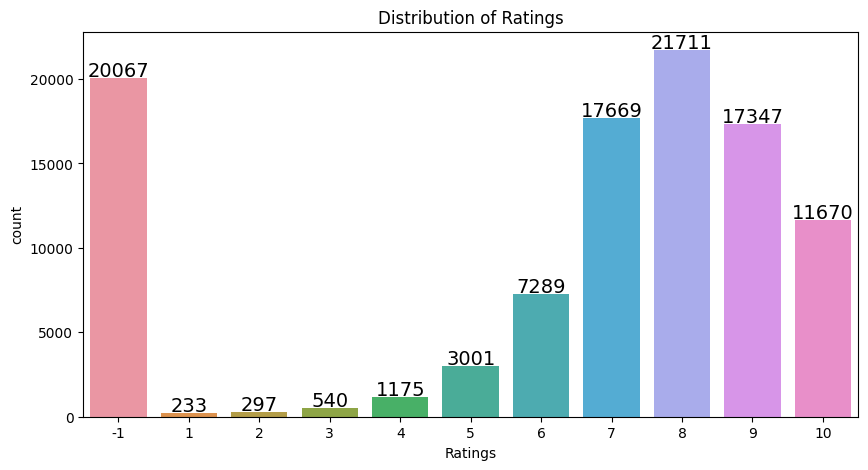

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=ratings_df, x='rating')
labels = (ratings_df['rating'].value_counts().sort_index())
plt.title('Distribution of Ratings')
plt.xlabel('Ratings')

for i,v in enumerate(labels):
    ax.text(i, v+100, str(v), horizontalalignment='center', size=14, color='black')
plt.show()

<b>4. Junte (merge) la información de los dos dataframes en uno solo relacionándolos por
el campo anime_id que esta en ambos.</b>

In [ ]:
df = pd.merge(ratings_df, anime_df[['anime_id', 'name']], left_on='anime_id', right_on='anime_id')
df.head(10)

,user_id,anime_id,rating,name
0,1,20,-1,Naruto
1,3,20,8,Naruto
2,5,20,6,Naruto
3,6,20,-1,Naruto
4,10,20,-1,Naruto
5,21,20,8,Naruto
6,28,20,9,Naruto
7,34,20,9,Naruto
8,38,20,6,Naruto
9,39,20,10,Naruto


<b>5. Genere el dataframe que requiere el algoritmo apriori en el que cada renglón
representa un usuario, cada columna es un anime y se rellena con ceros y unos
indicando para cada usuario si ha visto (1) o no (0) el anime.</b>

In [ ]:
df = df.drop_duplicates(['user_id','name'])
df_pivot = df.pivot(index='user_id', columns='name', values='rating').fillna(0)
df_pivot = df_pivot.astype('int64')
def encode_ratings(x):
    if x<=0:
        return 0
    if x>=1:
        return 1

df_pivot = df_pivot.applymap(encode_ratings)

In [ ]:
df_pivot.head()

name,&quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hatsukoi,&quot;Bungaku Shoujo&quot; Memoire,&quot;Bungaku Shoujo&quot; Movie,.hack//G.U. Returner,.hack//G.U. Trilogy,.hack//G.U. Trilogy: Parody Mode,.hack//Gift,.hack//Intermezzo,.hack//Liminality,.hack//Quantum,...,gdgd Fairies,gdgd Fairies 2,gdgd Fairies Movie: tte Iu Eiga wa Dou kana...?,iDOLM@STER Xenoglossia,s.CRY.ed,xxxHOLiC,xxxHOLiC Kei,xxxHOLiC Movie: Manatsu no Yoru no Yume,xxxHOLiC Rou,xxxHOLiC Shunmuki
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


<b>6. Obtenga los 5 animes más frecuentes que cuentan con un soporte mínimo del 7%.
El resultado debe estar ordenado de mayor a menor soporte.</b>

In [ ]:
from mlxtend.frequent_patterns import apriori
frequent_itemset = apriori(df_pivot, min_support=0.07, use_colnames=True)
frequent_itemset.sort_values('support', ascending = False).head(10)

C:\Users\rgaon\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:110: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
62,0.480695,(Death Note)
232,0.479730,(Sword Art Online)
216,0.442085,(Shingeki no Kyojin)
6,0.381274,(Angel Beats!)
164,0.354247,(Mirai Nikki (TV))
88,0.331081,(Fullmetal Alchemist: Brotherhood)
71,0.328185,(Elfen Lied)
3337,0.327220,"(Shingeki no Kyojin, Sword Art Online)"
109,0.317568,(Highschool of the Dead)
1844,0.312741,"(Shingeki no Kyojin, Death Note)"


<b>7.  Ahora obtenga las 5 reglas con mayor soporte usando un umbral del 30% (0.3)</b>


In [ ]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemset, metric="lift", min_threshold=0.3)
rules.sort_values('lift', ascending = False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
131855,"(Code Geass: Hangyaku no Lelouch, Black Lagoon...","(Code Geass: Hangyaku no Lelouch R2, Black Lag...",0.071429,0.083012,0.070463,0.986486,11.883721,0.064534,67.857143,0.986301
131858,"(Code Geass: Hangyaku no Lelouch R2, Black Lag...","(Code Geass: Hangyaku no Lelouch, Black Lagoon...",0.083012,0.071429,0.070463,0.848837,11.883721,0.064534,6.142857,0.998760
131856,"(Code Geass: Hangyaku no Lelouch, Black Lagoon)","(Code Geass: Hangyaku no Lelouch R2, Black Lag...",0.085907,0.070463,0.070463,0.820225,11.640449,0.064410,5.170548,1.000000
131857,"(Code Geass: Hangyaku no Lelouch R2, Black Lag...","(Code Geass: Hangyaku no Lelouch, Black Lagoon)",0.070463,0.085907,0.070463,1.000000,11.640449,0.064410,inf,0.983385
26036,"(Bakuman. 2nd Season, Bakuman.)",(Bakuman. 3rd Season),0.083977,0.073359,0.071429,0.850575,11.594676,0.065268,6.201366,0.997522


<b>8.Aplique el algoritmo apriori para obtener las 5 reglas con mayor lift usando un umbral
de 1.</b>

In [ ]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemset, metric="lift", min_threshold=1)
rules.sort_values('lift', ascending = False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
131855,"(Code Geass: Hangyaku no Lelouch, Black Lagoon...","(Code Geass: Hangyaku no Lelouch R2, Black Lag...",0.071429,0.083012,0.070463,0.986486,11.883721,0.064534,67.857143,0.986301
131858,"(Code Geass: Hangyaku no Lelouch R2, Black Lag...","(Code Geass: Hangyaku no Lelouch, Black Lagoon...",0.083012,0.071429,0.070463,0.848837,11.883721,0.064534,6.142857,0.998760
131856,"(Code Geass: Hangyaku no Lelouch, Black Lagoon)","(Code Geass: Hangyaku no Lelouch R2, Black Lag...",0.085907,0.070463,0.070463,0.820225,11.640449,0.064410,5.170548,1.000000
131857,"(Code Geass: Hangyaku no Lelouch R2, Black Lag...","(Code Geass: Hangyaku no Lelouch, Black Lagoon)",0.070463,0.085907,0.070463,1.000000,11.640449,0.064410,inf,0.983385
26036,"(Bakuman. 2nd Season, Bakuman.)",(Bakuman. 3rd Season),0.083977,0.073359,0.071429,0.850575,11.594676,0.065268,6.201366,0.997522


<b>9.Obtenga las 8 mejores reglas para determinar que le recomendaría a los usuarios que
han visto “Naruto” usando la métrica lift con un umbral de 2.</b>

In [ ]:
df_Naruto = rules[rules['antecedents'].apply(lambda x: len(x) ==1 and next(iter(x)) == 'Naruto')]
df_Naruto = df_Naruto[df_Naruto['lift'] > 2]
df_Naruto.sort_values('confidence', ascending = False).head(8)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
1457,(Naruto),(Bleach),0.287645,0.190154,0.124517,0.432886,2.276496,0.069820,1.428012,0.787147
3303,(Naruto),(Dragon Ball Z),0.287645,0.194015,0.115830,0.402685,2.075528,0.060023,1.349345,0.727439
43871,(Naruto),"(Fullmetal Alchemist, Death Note)",0.287645,0.186293,0.109073,0.379195,2.035470,0.055487,1.310727,0.714128
26783,(Naruto),"(Bleach, Death Note)",0.287645,0.135135,0.102317,0.355705,2.632215,0.063446,1.342342,0.870481
181773,(Naruto),"(Shingeki no Kyojin, Death Note, Fullmetal Alc...",0.287645,0.169884,0.100386,0.348993,2.054301,0.051520,1.275126,0.720450
51041,(Naruto),"(Fullmetal Alchemist, Shingeki no Kyojin)",0.287645,0.163127,0.096525,0.335570,2.057107,0.049602,1.259536,0.721382
43499,(Naruto),"(Death Note, Fairy Tail)",0.287645,0.149614,0.095560,0.332215,2.220481,0.052524,1.273443,0.771591
43025,(Naruto),"(Dragon Ball Z, Death Note)",0.287645,0.140927,0.095560,0.332215,2.357360,0.055023,1.286452,0.808300


<b>10.Genere una lista con los títulos de los animes del resultado anterior ordenándolos de
mayor a menor confianza.</b>

In [ ]:
anime = df_Naruto.sort_values('confidence', ascending = False)['consequents'].values

anime_list = []
for anime in anime:
    for title in anime:
        if title not in anime_list:
            anime_list.append(title)

In [ ]:
anime_list[0:10]

['Bleach',
 'Dragon Ball Z',
 'Fullmetal Alchemist',
 'Death Note',
 'Shingeki no Kyojin',
 'Fullmetal Alchemist: Brotherhood',
 'Fairy Tail',
 'Sword Art Online',
 'Code Geass: Hangyaku no Lelouch',
 'Ao no Exorcist']